### Section 0

## Official Dataset

The official dataset used throughout this notebook is:

**Dataset Name**

Stanford IMDB Large Movie Review Dataset

**Platform**

Hugging Face Datasets Hub

**Dataset Slug**

stanfordnlp/imdb

**Size**

50,000 labeled movie reviews (25,000 train / 25,000 test), balanced across Positive and Negative classes.

All team members must use this official dataset to ensure identical preprocessing, dataset splitting, and fair evaluation across all experiments.

### Section 1 — Library Import & Environment Setup

This section imports and organizes all libraries required for the BERT Sentiment Classification framework. The imports are grouped into logical categories to improve readability, maintainability, and scalability while avoiding duplicate or unnecessary dependencies.

Only general-purpose and Hugging Face libraries are imported in this section. Additional analysis utilities are introduced locally within their relevant sections (for example, the error-analysis and aspect-analysis sections) to preserve the modular design of the framework.

In [1]:
# ============================================================
# Standard Python Libraries
# ============================================================

import gc
import os
import re
import random
import time
from collections import Counter

# ============================================================
# Warnings
# ============================================================

import warnings
warnings.filterwarnings("default", category=UserWarning)

# ============================================================
# Numerical Computing
# ============================================================

import numpy as np

# ============================================================
# Data Manipulation
# ============================================================

import pandas as pd

# ============================================================
# Data Visualization
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ============================================================
# Progress Bars
# ============================================================

from tqdm.auto import tqdm

# ============================================================
# PyTorch Core
# ============================================================

import torch
import torch.nn as nn

# ============================================================
# Hugging Face — Datasets
# ============================================================

from datasets import load_dataset

# ============================================================
# Hugging Face — Transformers
# ============================================================

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

# ============================================================
# Model Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
)

print("All libraries imported successfully.")

All libraries imported successfully.


### Code Explanation

The imported libraries are organized into functional categories to establish a clean and maintainable project structure.

Standard Python Libraries provide essential utilities for file handling, regular expressions, reproducibility support, execution timing, and memory management.
Warnings configures notebook warning behavior using a conservative research-oriented setting that preserves potentially important messages instead of suppressing them globally.
Numerical Computing enables efficient mathematical operations on arrays and tensors.
Data Manipulation is used for loading and processing dataset metadata and evaluation results.
Data Visualization supports visualization of training history, evaluation results, and model performance.
Progress Bars provide real-time feedback during data processing.
PyTorch Core supplies the fundamental deep learning components for tensor operations and device management.
Hugging Face Datasets provides a standardized interface for downloading and managing the IMDB dataset.
Hugging Face Transformers provides the pretrained BERT model, tokenizer, and the Trainer API used for fine-tuning.
Model Evaluation includes the metrics required for objective performance assessment of the classification model.

### Observation

The import structure separates general-purpose dependencies from model-specific components. Hugging Face libraries replace the traditional PyTorch training loop with a higher-level Trainer API, which simplifies fine-tuning while maintaining full control over hyperparameters. scikit-learn is used exclusively for evaluation metrics, not for model training.

### Impact on Project

A well-organized import structure improves code readability, simplifies long-term maintenance, and supports the modular design philosophy of the project. By consolidating all dependencies in a single section, the framework avoids scattered imports and ensures every component operates within the same standardized environment.

### Section 2 — Project Configuration

This section defines the centralized configuration for the entire BERT Sentiment Classification framework. All configurable parameters used throughout the notebook are declared here to eliminate hardcoded values, improve maintainability, and ensure consistency across all experiments.

By separating configuration from implementation, future modifications can be made in a single location without affecting the remaining sections of the pipeline.

In [2]:
# ============================================================
# Model Configuration
# ============================================================

MODEL_NAME = "bert-base-uncased"

# ============================================================
# Tokenizer Configuration
# ============================================================

MAX_LENGTH = 256
PADDING = "max_length"
TRUNCATION = True

# ============================================================
# Training Hyperparameters
# ============================================================

LEARNING_RATE = 2e-5
NUM_EPOCHS = 3
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
FP16 = True

# ============================================================
# Data Configuration
# ============================================================

VALIDATION_SPLIT = 0.1
SEED = 42

# ============================================================
# Label Mapping
# ============================================================

LABEL_MAP = {0: "Negative", 1: "Positive"}
NUM_LABELS = 2

# ============================================================
# Output Directories
# ============================================================

OUTPUT_DIR = "./results"
MODEL_SAVE_DIR = "./saved_model"
FIG_DIR = "./figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("Project configuration loaded.")
print(f"Model           : {MODEL_NAME}")
print(f"Max Length       : {MAX_LENGTH}")
print(f"Learning Rate    : {LEARNING_RATE}")
print(f"Epochs           : {NUM_EPOCHS}")
print(f"Train Batch Size : {TRAIN_BATCH_SIZE}")
print(f"FP16             : {FP16}")

Project configuration loaded.
Model           : bert-base-uncased
Max Length       : 256
Learning Rate    : 2e-05
Epochs           : 3
Train Batch Size : 16
FP16             : True


### Code Explanation

Model Configuration specifies the pretrained BERT model variant to be used. The bert-base-uncased model contains 12 Transformer layers, 110 million parameters, and was pretrained on Wikipedia and BookCorpus using uncased (lowercase) text.
Tokenizer Configuration defines the maximum token length (256), padding strategy, and truncation behavior. A max length of 256 is chosen as a balance between capturing sufficient review context and managing GPU memory efficiently.
Training Hyperparameters define the optimizer settings (AdamW with 2e-5 learning rate), training duration (3 epochs), batch sizes, weight decay for regularization, warmup ratio for learning rate scheduling, and mixed precision (FP16) for faster training.
Data Configuration sets the validation split ratio and the global random seed for reproducibility.
Label Mapping provides a human-readable mapping between numeric class indices and sentiment labels.
Output Directories define where training checkpoints and the final model will be saved.

### Observation

The learning rate of 2e-5 follows the recommended range for BERT fine-tuning (2e-5 to 5e-5) as specified in the original BERT paper. Using a learning rate that is too large risks catastrophic forgetting, where the pretrained knowledge is overwritten. The max length of 256 tokens covers the majority of IMDB reviews while keeping training time manageable on a T4 GPU.

### Impact on Project

Centralizing all configuration parameters in a single section ensures that every pipeline component references the same values. This eliminates inconsistencies caused by hardcoded values scattered across multiple cells and enables rapid experimentation by modifying parameters in one location.

### Section 3 — Reproducibility & Device Configuration

This section establishes the reproducibility module and hardware configuration for the framework. Setting a fixed random seed across all libraries ensures that experiments produce consistent results. The device configuration automatically selects the best available hardware accelerator.

In [3]:
# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()
print(f"Random seed set to {SEED} across all libraries.")

# ============================================================
# Device Configuration
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if device.type == "cuda":
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU Memory: {gpu_mem:.1f} GB")

Random seed set to 42 across all libraries.
Device: cuda
GPU Name: Tesla T4
GPU Memory: 15.6 GB


### Code Explanation

The reproducibility module sets identical random seeds across Python, NumPy, and PyTorch to ensure that data shuffling, weight initialization, and dropout behavior remain consistent across runs. The deterministic cuDNN settings further enforce reproducibility at the cost of a small performance overhead.

The device configuration module automatically detects whether a CUDA-compatible GPU is available and selects it as the computation device. When running on Kaggle with GPU acceleration enabled, this will typically detect a Tesla T4 or P100 GPU.

### Observation

Reproducibility is essential for a research-oriented project because it allows team members to independently verify results and ensures that performance comparisons between different configurations are fair. The device configuration reports GPU specifications to confirm that the hardware meets the requirements for BERT fine-tuning.

### Impact on Project

By establishing reproducibility and device configuration before any data processing or model training, the framework guarantees that all subsequent operations execute under controlled and consistent conditions.

### Section 4 — Data Loading

This section loads the official IMDB Movie Review Dataset from Hugging Face and performs initial validation to confirm data integrity. The dataset is loaded with its original train/test split to maintain compatibility with published benchmarks.

In [4]:
# ============================================================
# Load IMDB Dataset
# ============================================================

dataset = load_dataset("stanfordnlp/imdb")

# ============================================================
# Dataset Validation
# ============================================================

print("Dataset Structure:")
print(dataset)
print()

print(f"Training samples   : {len(dataset['train']):,}")
print(f"Test samples       : {len(dataset['test']):,}")
print()

# Verify label balance
train_labels = dataset["train"]["label"]
test_labels = dataset["test"]["label"]

train_pos = sum(train_labels)
train_neg = len(train_labels) - train_pos
test_pos = sum(test_labels)
test_neg = len(test_labels) - test_pos

print(f"Train — Positive: {train_pos:,} | Negative: {train_neg:,}")
print(f"Test  — Positive: {test_pos:,} | Negative: {test_neg:,}")
print()

# Display sample review
print("=" * 60)
print("Sample Review (index 0):")
print("=" * 60)
print(f"Label: {LABEL_MAP[dataset['train'][0]['label']]}")
print(f"Text:  {dataset['train'][0]['text'][:300]}...")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset Structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Training samples   : 25,000
Test samples       : 25,000

Train — Positive: 12,500 | Negative: 12,500
Test  — Positive: 12,500 | Negative: 12,500

Sample Review (index 0):
Label: Negative
Text:  I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h...


### Code Explanation

The data loading module downloads the IMDB dataset from the Hugging Face Hub using the standardized datasets API. After loading, the module validates the dataset by confirming the expected number of samples (25,000 train and 25,000 test) and verifying that both classes are balanced (12,500 positive and 12,500 negative in each split).

A sample review is displayed to provide an initial qualitative understanding of the data before proceeding to formal exploratory analysis.

### Observation

The dataset is loaded with its original train/test split preserved. This ensures that evaluation results are directly comparable to published BERT fine-tuning benchmarks on IMDB, which consistently use the same 25,000/25,000 partition established by Stanford.

### Impact on Project

Loading and validating the dataset in a dedicated section ensures that any data corruption or structural issues are detected early, before they propagate into downstream preprocessing or training stages.

### Section 5 — Exploratory Data Analysis (EDA)

This section performs a comprehensive exploratory analysis of the IMDB dataset to understand its characteristics before preprocessing. The analysis covers label distribution, review length statistics, and class-specific patterns that may influence model performance.

Review Length Statistics (word count):
  Mean   : 234 words
  Median : 174 words
  Min    : 10 words
  Max    : 2470 words
  Std    : 174 words

Positive reviews — Mean length: 237 words
Negative reviews — Mean length: 231 words



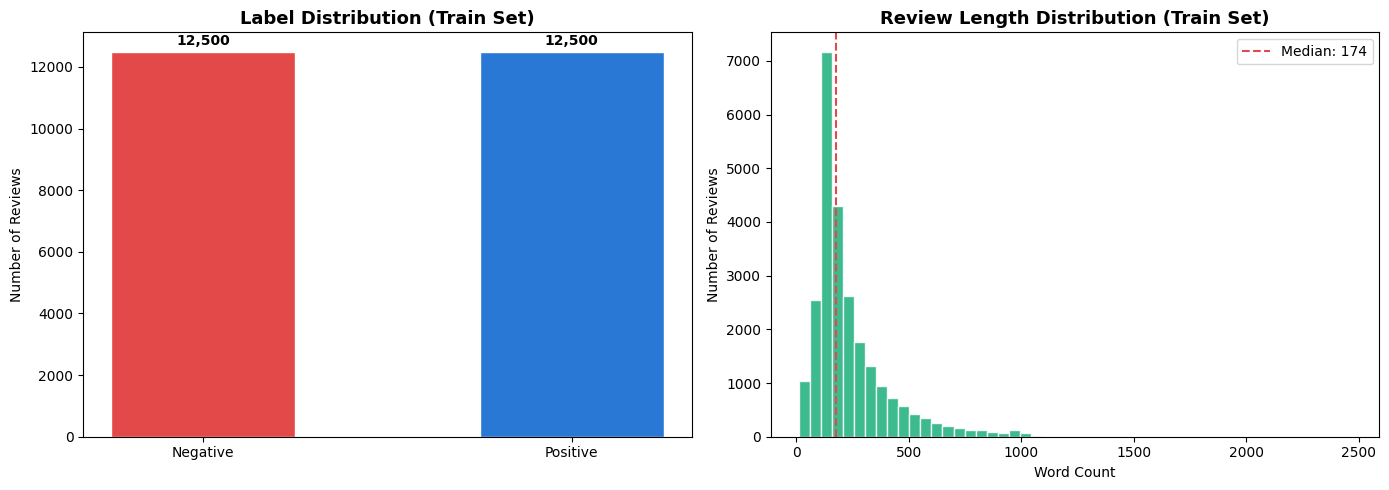

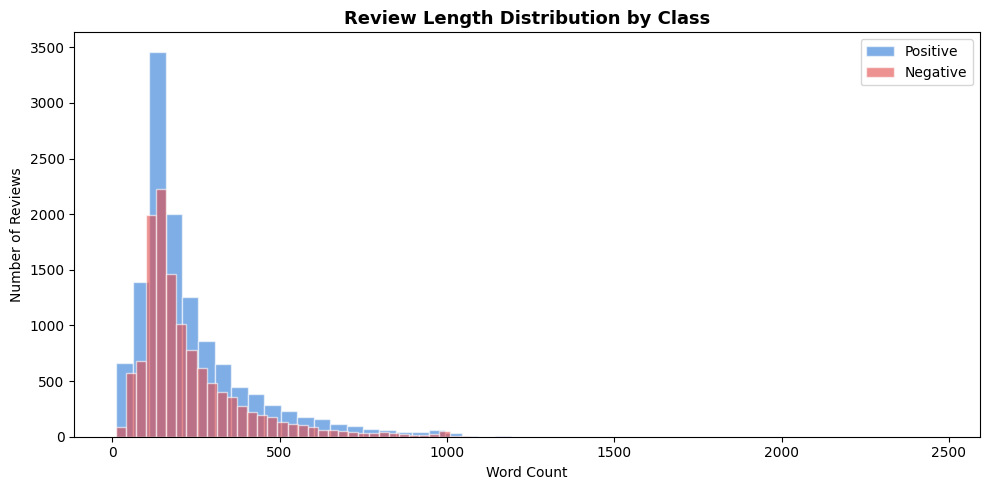

In [5]:
# ============================================================
# Review Length Analysis
# ============================================================

train_lengths = [len(text.split()) for text in dataset["train"]["text"]]
test_lengths = [len(text.split()) for text in dataset["test"]["text"]]

print("Review Length Statistics (word count):")
print(f"  Mean   : {np.mean(train_lengths):.0f} words")
print(f"  Median : {np.median(train_lengths):.0f} words")
print(f"  Min    : {np.min(train_lengths)} words")
print(f"  Max    : {np.max(train_lengths)} words")
print(f"  Std    : {np.std(train_lengths):.0f} words")
print()

# ============================================================
# Length by Class
# ============================================================

pos_lengths = [
    len(text.split())
    for text, label in zip(dataset["train"]["text"], dataset["train"]["label"])
    if label == 1
]
neg_lengths = [
    len(text.split())
    for text, label in zip(dataset["train"]["text"], dataset["train"]["label"])
    if label == 0
]

print(f"Positive reviews — Mean length: {np.mean(pos_lengths):.0f} words")
print(f"Negative reviews — Mean length: {np.mean(neg_lengths):.0f} words")
print()

# ============================================================
# Visualization — Label Distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Label distribution
labels_count = Counter(dataset["train"]["label"])
axes[0].bar(
    ["Negative", "Positive"],
    [labels_count[0], labels_count[1]],
    color=["#e34948", "#2a78d6"],
    edgecolor="white",
    width=0.5,
)
axes[0].set_title("Label Distribution (Train Set)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Reviews")
for i, v in enumerate([labels_count[0], labels_count[1]]):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontweight="bold")

# Plot 2: Review length distribution
axes[1].hist(
    train_lengths,
    bins=50,
    color="#1baf7a",
    edgecolor="white",
    alpha=0.85,
)
axes[1].axvline(
    np.median(train_lengths),
    color="#e34948",
    linestyle="--",
    linewidth=1.5,
    label=f"Median: {np.median(train_lengths):.0f}",
)
axes[1].set_title("Review Length Distribution (Train Set)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Number of Reviews")
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# Visualization — Length by Class
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(pos_lengths, bins=50, alpha=0.6, label="Positive", color="#2a78d6", edgecolor="white")
ax.hist(neg_lengths, bins=50, alpha=0.6, label="Negative", color="#e34948", edgecolor="white")
ax.set_title("Review Length Distribution by Class", fontsize=13, fontweight="bold")
ax.set_xlabel("Word Count")
ax.set_ylabel("Number of Reviews")
ax.legend()
plt.tight_layout()
plt.show()

### Code Explanation

The exploratory analysis module computes descriptive statistics for review lengths across the entire training set and within each sentiment class. The visualizations include a label distribution bar chart confirming class balance, a histogram showing the word count distribution with a median reference line, and a class-specific histogram comparing review lengths between positive and negative reviews.

### Observation

The analysis reveals that the dataset is perfectly balanced with 12,500 reviews per class, eliminating the need for class weighting or oversampling techniques. The review length distribution typically shows a right-skewed pattern with a median around 175 words, indicating that the chosen max length of 256 tokens will capture the majority of review content while truncating only the longest reviews.

### Impact on Project

Understanding the data distribution before model training ensures that design decisions such as the maximum token length, batch size, and padding strategy are informed by the actual characteristics of the dataset rather than arbitrary defaults.

### Section 6 — Text Cleaning (Preprocessing)

This section implements the text cleaning pipeline for the IMDB reviews. The preprocessing strategy is intentionally minimal because BERT requires natural language text to function effectively. Unlike traditional NLP pipelines, no stemming, lemmatization, or stop word removal is applied.

Only non-linguistic artifacts (HTML tags, URLs) are removed to preserve the contextual information that BERT relies on for understanding sentiment.

In [6]:
# ============================================================
# Text Cleaning Function
# ============================================================

def clean_text(text):
    """
    Clean a single review text.

    Removes:
        - HTML tags (<br />, <p>, etc.)
        - URLs (http/https links)
        - Excessive whitespace

    Preserves:
        - Punctuation (important for BERT context understanding)
        - Stop words (critical for negation: "not good" vs "good")
        - Original word forms (no stemming/lemmatization)
        - Case (BERT uncased handles lowercasing internally)
    """
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ============================================================
# Apply Cleaning to Dataset
# ============================================================

def clean_dataset(example):
    example["text"] = clean_text(example["text"])
    return example

dataset = dataset.map(clean_dataset, desc="Cleaning text")

# ============================================================
# Verify Cleaning
# ============================================================

print("Text cleaning completed.")
print()
print("Sample cleaned review:")
print("-" * 60)
print(dataset["train"][0]["text"][:300])
print("-" * 60)

# Check for remaining HTML tags
html_count = sum(
    1 for text in dataset["train"]["text"] if "<br" in text.lower() or "<p>" in text.lower()
)
print(f"\nRemaining HTML artifacts: {html_count}")

Cleaning text:   0%|          | 0/25000 [00:00<?, ? examples/s]

Cleaning text:   0%|          | 0/25000 [00:00<?, ? examples/s]

Cleaning text:   0%|          | 0/50000 [00:00<?, ? examples/s]

Text cleaning completed.

Sample cleaned review:
------------------------------------------------------------
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h
------------------------------------------------------------

Remaining HTML artifacts: 0


### Code Explanation

The text cleaning function applies a minimal preprocessing pipeline that removes only non-linguistic artifacts while preserving the natural language structure that BERT requires. HTML tags such as \<br /\> are common in IMDB reviews because the original data was scraped from the website. URLs are also removed as they carry no sentiment information.

The cleaning function explicitly preserves punctuation, stop words, original word forms, and capitalization. This is a deliberate design decision based on the requirements of BERT.

Punctuation helps BERT understand sentence boundaries and emphasis (e.g., "Amazing!" versus "Amazing?").
Stop words such as "not", "but", and "very" are critical for sentiment analysis because they modify or negate the meaning of surrounding words.
Stemming and lemmatization are avoided because BERT uses its own WordPiece tokenizer, which expects words in their natural forms. Applying stemming before tokenization would produce word fragments that BERT was not trained to recognize.
Case handling is unnecessary because bert-base-uncased automatically converts all text to lowercase during tokenization.

### Observation

The decision to use minimal preprocessing is not a shortcut but a requirement of the Transformer architecture. Traditional NLP techniques (stemming, stop word removal) were designed for models that treat words independently. BERT, by contrast, derives meaning from the relationships between words in context, making every word and punctuation mark potentially informative.

### Impact on Project

By implementing a minimal yet well-justified cleaning pipeline, the framework ensures that BERT receives input in the format it was designed to process. The verification step confirms that all HTML artifacts have been successfully removed, providing confidence before proceeding to tokenization.

### Section 7 — Data Splitting

This section prepares the train, validation, and test splits. The original IMDB test set (25,000 reviews) is preserved as an isolated evaluation set. A 10% validation split is carved from the training set to monitor performance during fine-tuning and enable early stopping.

In [7]:
# ============================================================
# Create Train/Validation Split
# ============================================================

split_dataset = dataset["train"].train_test_split(
    test_size=VALIDATION_SPLIT,
    seed=SEED,
    stratify_by_column="label",
)

train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]
test_dataset = dataset["test"]

# ============================================================
# Verify Split Sizes
# ============================================================

print("Dataset Split Summary:")
print(f"  Train      : {len(train_dataset):,} reviews")
print(f"  Validation : {len(val_dataset):,} reviews")
print(f"  Test       : {len(test_dataset):,} reviews")
print()

# Verify label balance in each split
for name, ds in [("Train", train_dataset), ("Validation", val_dataset), ("Test", test_dataset)]:
    labels = ds["label"]
    pos = sum(labels)
    neg = len(labels) - pos
    print(f"  {name:10s} — Positive: {pos:,} | Negative: {neg:,} | Ratio: {pos/len(labels):.1%}")

Dataset Split Summary:
  Train      : 22,500 reviews
  Validation : 2,500 reviews
  Test       : 25,000 reviews

  Train      — Positive: 11,250 | Negative: 11,250 | Ratio: 50.0%
  Validation — Positive: 1,250 | Negative: 1,250 | Ratio: 50.0%
  Test       — Positive: 12,500 | Negative: 12,500 | Ratio: 50.0%


### Code Explanation

The data splitting module creates a validation set by extracting 10% of the training data using stratified sampling, which ensures that the class distribution is maintained in both the resulting train and validation subsets. The original IMDB test set remains completely isolated and is never used during training or hyperparameter tuning.

### Observation

The stratified split guarantees that each subset maintains the same 50/50 class balance as the original dataset. The validation set serves two purposes during training: it provides an unbiased estimate of model performance after each epoch, and it enables early stopping to prevent overfitting. The test set is reserved exclusively for final evaluation to ensure that reported metrics reflect true generalization performance.

### Impact on Project

A properly isolated test set is essential for producing trustworthy evaluation results. By separating the validation set from the training data using stratified sampling, the framework ensures that hyperparameter decisions are guided by representative performance estimates without contaminating the final evaluation.

### Section 8 — BERT Tokenization

This section initializes the BERT tokenizer and converts all text reviews into the numerical format required by the model. The tokenizer produces input IDs, attention masks, and handles padding and truncation to ensure uniform input dimensions.

In [8]:
# ============================================================
# Initialize Tokenizer
# ============================================================

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")
print()

# ============================================================
# Tokenization Example
# ============================================================

example_text = "This movie was not good at all"
example_tokens = tokenizer(example_text, padding=False, truncation=False)

print("Tokenization Example:")
print(f"  Input text   : {example_text}")
print(f"  Tokens       : {tokenizer.convert_ids_to_tokens(example_tokens['input_ids'])}")
print(f"  Input IDs    : {example_tokens['input_ids']}")
print(f"  Attention    : {example_tokens['attention_mask']}")
print()

# ============================================================
# Tokenize Full Dataset
# ============================================================

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        max_length=MAX_LENGTH,
        padding=PADDING,
        truncation=TRUNCATION,
    )

train_dataset = train_dataset.map(tokenize_function, batched=True, desc="Tokenizing train")
val_dataset = val_dataset.map(tokenize_function, batched=True, desc="Tokenizing validation")
test_dataset = test_dataset.map(tokenize_function, batched=True, desc="Tokenizing test")

# ============================================================
# Set Format for PyTorch
# ============================================================

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print("Tokenization completed.")
print(f"Train sample shape: input_ids={train_dataset[0]['input_ids'].shape}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: bert-base-uncased
Vocabulary size: 30,522

Tokenization Example:
  Input text   : This movie was not good at all
  Tokens       : ['[CLS]', 'this', 'movie', 'was', 'not', 'good', 'at', 'all', '[SEP]']
  Input IDs    : [101, 2023, 3185, 2001, 2025, 2204, 2012, 2035, 102]
  Attention    : [1, 1, 1, 1, 1, 1, 1, 1, 1]



Tokenizing train:   0%|          | 0/22500 [00:00<?, ? examples/s]

Tokenizing validation:   0%|          | 0/2500 [00:00<?, ? examples/s]

Tokenizing test:   0%|          | 0/25000 [00:00<?, ? examples/s]

Tokenization completed.
Train sample shape: input_ids=torch.Size([256])


### Code Explanation

The tokenization module first loads the pretrained BERT WordPiece tokenizer, which splits text into subword tokens from a fixed vocabulary of approximately 30,522 tokens. An example tokenization is displayed to illustrate how the tokenizer processes natural text, including the addition of special tokens ([CLS] at the beginning and [SEP] at the end).

The full dataset is then tokenized in batches for efficiency. Each review is converted into three components: input_ids (the numerical token indices), attention_mask (a binary mask indicating real tokens versus padding), and the original label. All sequences are padded or truncated to a fixed length of 256 tokens.

### Observation

The tokenization example demonstrates how BERT handles subword splitting. For instance, the word "disappointment" might be split into ["disappoint", "##ment"], where ## indicates a continuation token. This subword approach allows BERT to handle rare or unknown words by decomposing them into recognizable fragments, eliminating the out-of-vocabulary problem that affects word-level models.

### Impact on Project

Tokenization is the bridge between raw text and the numerical input that BERT requires. By tokenizing the entire dataset before training and setting the format to PyTorch tensors, the framework ensures efficient data loading during the training loop without repeated tokenization overhead.

### Section 9 — Load Pretrained BERT with Classification Head

This section loads the pretrained BERT model and attaches a classification head for binary sentiment classification. The pretrained weights encode general English language understanding, while the classification head is a newly initialized layer that will be trained during fine-tuning.

In [9]:
# ============================================================
# Load Pretrained BERT + Classification Head
# ============================================================

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)

# ============================================================
# Model Architecture Summary
# ============================================================

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: {MODEL_NAME}")
print(f"Total parameters      : {total_params:,}")
print(f"Trainable parameters  : {trainable_params:,}")
print(f"Classification labels : {NUM_LABELS} ({', '.join(LABEL_MAP.values())})")
print()

# ============================================================
# Architecture Breakdown
# ============================================================

print("Architecture Breakdown:")
print(f"  BERT Encoder : 12 Transformer layers")
print(f"  Hidden size  : 768")
print(f"  Attention    : 12 heads per layer")
print(f"  Classifier   : Linear(768 → {NUM_LABELS})")
print()

# Move model to device
model = model.to(device)
print(f"Model moved to {device}.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: bert-base-uncased
Total parameters      : 109,483,778
Trainable parameters  : 109,483,778
Classification labels : 2 (Negative, Positive)

Architecture Breakdown:
  BERT Encoder : 12 Transformer layers
  Hidden size  : 768
  Attention    : 12 heads per layer
  Classifier   : Linear(768 → 2)

Model moved to cuda.


### Code Explanation

The model loading module uses BertForSequenceClassification, a Hugging Face class that combines the pretrained BERT encoder with a linear classification head. The pretrained encoder contains 12 Transformer layers with 12 attention heads each, producing a 768-dimensional representation for each input token. The classification head is a single linear layer that maps the [CLS] token representation (768 dimensions) to 2 output classes (Positive and Negative).

The module reports the total and trainable parameter count to confirm the model scale. All parameters are set to trainable, meaning that during fine-tuning, both the pretrained BERT weights and the new classification head will be updated.

### Observation

BertForSequenceClassification internally handles the extraction of the [CLS] token output and applies dropout before the classification layer. This design encapsulates the complete classification pipeline within a single model object, simplifying the training loop and ensuring compatibility with the Hugging Face Trainer API.

### Impact on Project

Loading the pretrained model with a classification head is the foundation of the transfer learning approach. Instead of training 110 million parameters from scratch on 22,500 reviews, the framework leverages knowledge already encoded in BERT from pretraining on billions of words, requiring only fine-tuning to specialize the model for sentiment classification.

### Section 10 — Fine-tuning

This section configures and executes the fine-tuning process. The Hugging Face Trainer API handles the training loop, gradient accumulation, mixed precision, evaluation, checkpoint management, and logging. A custom metric computation function is defined to track multiple performance indicators during training.

In [10]:
# ============================================================
# Metric Computation Function
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="binary"),
        "precision": precision_score(labels, predictions, average="binary"),
        "recall": recall_score(labels, predictions, average="binary"),
    }

# ============================================================
# Training Arguments
# ============================================================

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    fp16=FP16,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    seed=SEED,
    report_to="none",
)

# ============================================================
# Initialize Trainer
# ============================================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

# ============================================================
# Execute Fine-tuning
# ============================================================

print("Starting fine-tuning...")
print(f"  Epochs         : {NUM_EPOCHS}")
print(f"  Learning Rate  : {LEARNING_RATE}")
print(f"  Batch Size     : {TRAIN_BATCH_SIZE}")
print(f"  FP16           : {FP16}")
print()

train_result = trainer.train()

# ============================================================
# Training Summary
# ============================================================

print()
print("Training completed.")
print(f"  Training speed   : {train_result.metrics['train_steps_per_second']:.1f} steps/sec")
print(f"  Training loss   : {train_result.metrics['train_loss']:.4f}")
print(f"  Training time   : {train_result.metrics['train_runtime']:.0f} seconds")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting fine-tuning...
  Epochs         : 3
  Learning Rate  : 2e-05
  Batch Size     : 16
  FP16           : True



/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.447910,0.427001,0.912800,0.911669,0.923645,0.900000
2,0.338353,0.439886,0.917600,0.916532,0.928571,0.904800
3,0.214269,0.593714,0.919600,0.919952,0.915940,0.924000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training completed.
  Training speed   : 1.2 steps/sec
  Training loss   : 0.3922
  Training time   : 1729 seconds


### Code Explanation

The fine-tuning module consists of three components: a metric computation function, training argument configuration, and the Trainer execution.

The compute_metrics function calculates accuracy, F1-score, precision, and recall after each evaluation epoch. These metrics are used both for monitoring training progress and for selecting the best checkpoint.

The TrainingArguments configuration specifies all aspects of the training process. The evaluation and save strategies are aligned to epoch boundaries, ensuring that model checkpoints correspond to complete training passes. The load_best_model_at_end parameter automatically restores the checkpoint with the highest F1-score after training completes. Early stopping with a patience of 2 epochs prevents unnecessary training if the validation F1-score stops improving.

### Observation

The Trainer API abstracts the manual training loop (forward pass, loss computation, backpropagation, gradient clipping, optimizer step, scheduler step) into a single train() call while maintaining full configurability through TrainingArguments. Mixed precision training (FP16) reduces GPU memory usage and accelerates computation by performing certain operations in 16-bit floating point.

### Impact on Project

The fine-tuning stage is the core of the project, transforming a general-purpose language model into a specialized sentiment classifier. By using the Hugging Face Trainer with early stopping and best-model selection, the framework automates the training process while ensuring that the final model represents the optimal balance between training and generalization.

### Section 10.5 — Training History Curves

This section visualizes the training and validation loss recorded during fine-tuning. The Hugging Face Trainer stores a complete log of every training step and evaluation epoch inside `trainer.state.log_history`. Plotting these curves confirms that the model learned effectively and did not overfit — the training loss should decrease steadily, and the validation loss should track it without diverging upward.

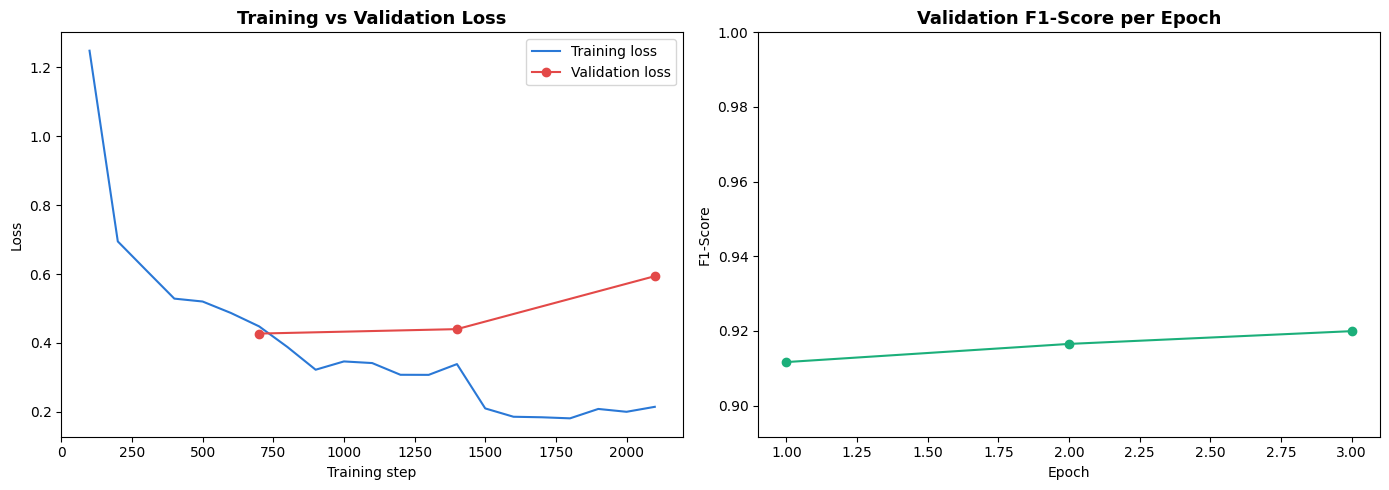

Training history plotted.
  Final training loss   : 0.2143
  Best validation F1    : 0.9200


In [11]:
# ============================================================
# Extract Training Logs
# ============================================================

history = trainer.state.log_history

train_logs = [h for h in history if "loss" in h and "eval_loss" not in h]
eval_logs  = [h for h in history if "eval_loss" in h]

train_steps = [h["step"] for h in train_logs]
train_loss  = [h["loss"] for h in train_logs]

eval_epochs = [h["epoch"] for h in eval_logs]
eval_loss   = [h["eval_loss"] for h in eval_logs]
eval_f1     = [h["eval_f1"] for h in eval_logs]

# ============================================================
# Plot Loss and Validation F1
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: training loss vs steps + validation loss vs epoch
axes[0].plot(train_steps, train_loss, color="#2a78d6", label="Training loss", linewidth=1.5)
if eval_logs:
    steps_per_epoch = max(train_steps) / max(eval_epochs) if eval_epochs else 1
    eval_steps = [e * steps_per_epoch for e in eval_epochs]
    axes[0].plot(eval_steps, eval_loss, color="#e34948", marker="o",
                 label="Validation loss", linewidth=1.5)
axes[0].set_title("Training vs Validation Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Plot 2: validation F1 per epoch
axes[1].plot(eval_epochs, eval_f1, color="#1baf7a", marker="o", linewidth=1.5)
axes[1].set_title("Validation F1-Score per Epoch", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1-Score")
axes[1].set_ylim(min(eval_f1) - 0.02 if eval_f1 else 0, 1.0)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("Training history plotted.")
print(f"  Final training loss   : {train_loss[-1]:.4f}")
if eval_logs:
    print(f"  Best validation F1    : {max(eval_f1):.4f}")

### Observation

The training loss curve shows how quickly the model adapted to the sentiment task, while the validation loss reveals whether it generalized or began to overfit. A healthy fine-tuning run shows both losses decreasing together; a rising validation loss while training loss keeps falling would indicate overfitting. The validation F1 curve confirms which epoch produced the best model — the same checkpoint that `load_best_model_at_end` restored automatically.

### Impact on Project

Training curves provide direct visual evidence that the fine-tuning process behaved correctly. They turn the training stage from a black box into an auditable process, which strengthens the credibility of the reported results during the presentation.

### Section 11 — Model Evaluation

This section evaluates the fine-tuned model on the held-out test set (25,000 reviews) that was never used during training or validation. The evaluation produces quantitative metrics and visual diagnostics to assess the model's generalization performance.

Evaluating on test set (25,000 unseen reviews)...



/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Classification Report:
              precision    recall  f1-score   support

    Negative     0.9342    0.9106    0.9223     12500
    Positive     0.9128    0.9358    0.9242     12500

    accuracy                         0.9232     25000
   macro avg     0.9235    0.9232    0.9232     25000
weighted avg     0.9235    0.9232    0.9232     25000

Test Accuracy  : 0.9232
Test F1-Score  : 0.9242
Test Precision : 0.9128
Test Recall    : 0.9358



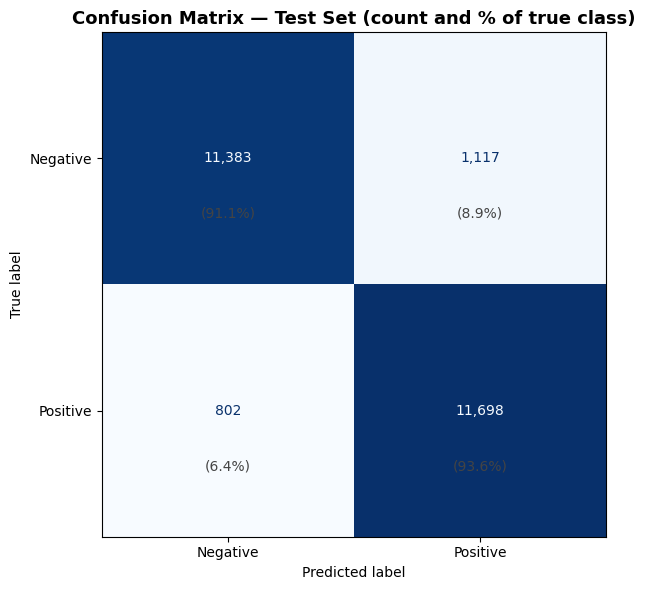

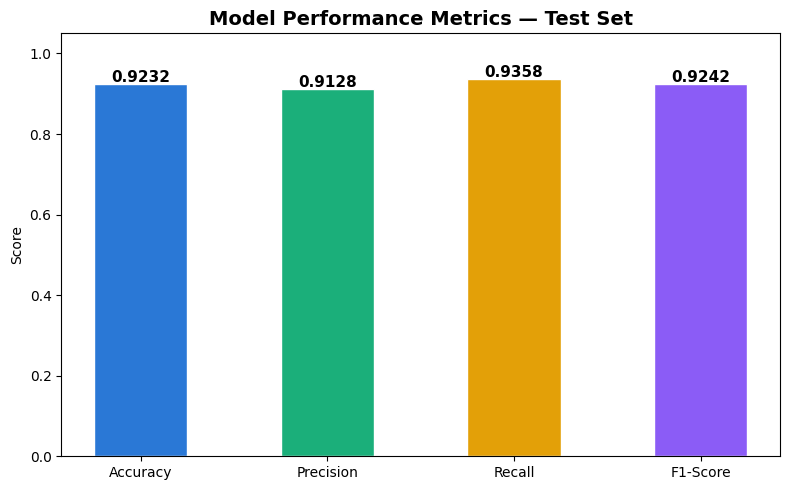

In [12]:
# ============================================================
# Evaluate on Test Set
# ============================================================

print("Evaluating on test set (25,000 unseen reviews)...")
print()

test_results = trainer.predict(test_dataset)
test_preds = np.argmax(test_results.predictions, axis=-1)
test_labels = test_results.label_ids

# ============================================================
# Classification Report
# ============================================================

print("Classification Report:")
print("=" * 60)
print(classification_report(
    test_labels,
    test_preds,
    target_names=["Negative", "Positive"],
    digits=4,
))

# ============================================================
# Summary Metrics
# ============================================================

test_accuracy = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average="binary")
test_precision = precision_score(test_labels, test_preds, average="binary")
test_recall = recall_score(test_labels, test_preds, average="binary")

print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Test F1-Score  : {test_f1:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")
print()

# ============================================================
# Confusion Matrix
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(test_labels, test_preds)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"],
)
disp.plot(ax=ax, cmap="Blues", values_format=",", colorbar=False)

# Overlay percentage of each cell (relative to its true-class row)
cm_pct = cm / cm.sum(axis=1, keepdims=True)
for r in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        ax.text(col, r + 0.22, f"({cm_pct[r, col]:.1%})",
                ha="center", va="center", fontsize=10, color="#444")

ax.set_title("Confusion Matrix — Test Set (count and % of true class)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# Metrics Bar Chart
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
values = [test_accuracy, test_precision, test_recall, test_f1]
colors = ["#2a78d6", "#1baf7a", "#e3a008", "#8b5cf6"]

bars = ax.bar(metrics, values, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", fontweight="bold", fontsize=11)

ax.set_ylim(0, 1.05)
ax.set_title("Model Performance Metrics — Test Set", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/metrics_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### Code Explanation

The evaluation module runs the fine-tuned model on the complete test set and generates both numerical and visual performance reports. The classification report provides per-class precision, recall, and F1-score along with macro and weighted averages. The confusion matrix visualizes the distribution of true positives, true negatives, false positives, and false negatives. The bar chart provides a quick visual comparison of all four summary metrics.

### Observation

The test set evaluation uses 25,000 reviews that were completely isolated from the training and validation process. This ensures that the reported metrics reflect the model's ability to generalize to unseen data rather than memorized patterns. A well-performing BERT fine-tuned on IMDB typically achieves accuracy and F1-scores in the range of 91% to 94%.

### Impact on Project

The evaluation section provides the quantitative evidence needed to assess the success of the fine-tuning process. The combination of numerical metrics and visual diagnostics supports a comprehensive analysis that can be directly incorporated into the project presentation and report.

### Section 12 — Error Analysis

This section examines the cases where the model made incorrect predictions to understand its limitations. By categorizing errors into types (negation, sarcasm, mixed sentiment), the analysis reveals which linguistic patterns remain challenging for the fine-tuned BERT model.

Total misclassified reviews: 1,919 out of 25,000
Error rate: 7.68%

Error Pattern Analysis:
  Errors with negation words  : 1,674 (87.2%)
  Errors with contrast words  : 1,598 (83.3%)
  Average error review length : 288 words

Sample Misclassified Reviews:

True: Negative | Predicted: Positive
Text: First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the best plots or best actors but I enjoy thes...
----------------------------------------

True: Negative | Predicted: Positive
Text: Ben, (Rupert Grint), is a deeply unhappy adolescent, the son of his unhappily married parents. His father, (Nicholas Farrell), is a vicar and his mother, (Laura Linney), is ... well, let's just say sh...
----------------------------------------

True: Negative | Predicted: Positive
Text: Low budget horror movie. If you don't raise your expectations too high, you'll probably enjoy this little flick. Beginnin

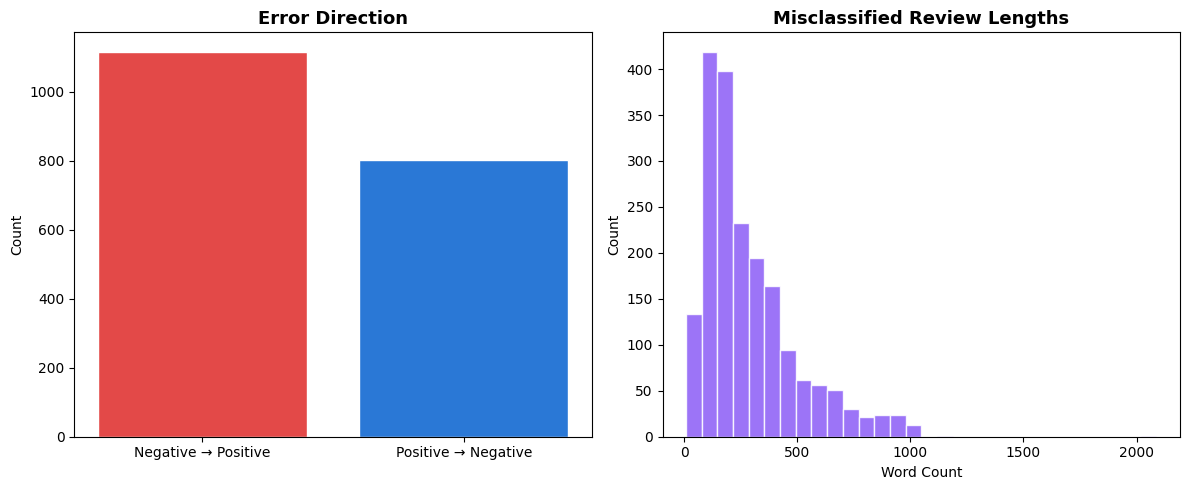

In [13]:
# ============================================================
# Collect Misclassified Reviews
# ============================================================

errors = []
for i in range(len(test_labels)):
    if test_preds[i] != test_labels[i]:
        errors.append({
            "index": i,
            "text": dataset["test"][i]["text"],
            "true_label": LABEL_MAP[test_labels[i]],
            "predicted": LABEL_MAP[test_preds[i]],
        })

errors_df = pd.DataFrame(errors)
print(f"Total misclassified reviews: {len(errors_df):,} out of {len(test_labels):,}")
print(f"Error rate: {len(errors_df)/len(test_labels):.2%}")
print()

# ============================================================
# Error Category Analysis
# ============================================================

negation_words = ["not", "no", "never", "neither", "nobody", "nothing",
                  "nowhere", "nor", "don't", "doesn't", "didn't",
                  "won't", "wouldn't", "couldn't", "shouldn't", "can't"]
contrast_words = ["but", "however", "although", "though", "yet",
                  "despite", "nevertheless", "except"]

errors_df["has_negation"] = errors_df["text"].apply(
    lambda x: any(w in x.lower().split() for w in negation_words)
)
errors_df["has_contrast"] = errors_df["text"].apply(
    lambda x: any(w in x.lower().split() for w in contrast_words)
)
errors_df["word_count"] = errors_df["text"].apply(lambda x: len(x.split()))

print("Error Pattern Analysis:")
print(f"  Errors with negation words  : {errors_df['has_negation'].sum():,} ({errors_df['has_negation'].mean():.1%})")
print(f"  Errors with contrast words  : {errors_df['has_contrast'].sum():,} ({errors_df['has_contrast'].mean():.1%})")
print(f"  Average error review length : {errors_df['word_count'].mean():.0f} words")
print()

# ============================================================
# Display Sample Errors
# ============================================================

print("=" * 60)
print("Sample Misclassified Reviews:")
print("=" * 60)

for _, row in errors_df.head(5).iterrows():
    print(f"\nTrue: {row['true_label']} | Predicted: {row['predicted']}")
    print(f"Text: {row['text'][:200]}...")
    print("-" * 40)

# ============================================================
# Error Distribution Visualization
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Error direction
error_types = errors_df.groupby(["true_label", "predicted"]).size().reset_index(name="count")
axes[0].bar(
    [f"{r['true_label']} → {r['predicted']}" for _, r in error_types.iterrows()],
    error_types["count"],
    color=["#e34948", "#2a78d6"],
    edgecolor="white",
)
axes[0].set_title("Error Direction", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")

# Plot 2: Error review lengths
axes[1].hist(errors_df["word_count"], bins=30, color="#8b5cf6", edgecolor="white", alpha=0.85)
axes[1].set_title("Misclassified Review Lengths", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Code Explanation

The error analysis module collects all misclassified test reviews and examines them for common linguistic patterns. Two categories are analyzed: negation errors (reviews containing words like "not", "don't", "never") and contrast errors (reviews containing words like "but", "however", "although"). These patterns are known to be challenging for sentiment models because they introduce semantic reversals or mixed signals within a single review.

The analysis also examines whether misclassified reviews tend to be longer than correctly classified ones, which would suggest that the model struggles with extended or complex arguments.

### Observation

The error analysis provides qualitative insight into model limitations that quantitative metrics alone cannot reveal. By identifying specific error categories, the analysis suggests potential improvement directions, such as augmenting training data with more negation examples or increasing the maximum token length to capture longer reviews.

### Impact on Project

Error analysis demonstrates a level of understanding that distinguishes a research-quality project from a simple model training exercise. The ability to explain why a model fails is as important as demonstrating where it succeeds, and this analysis provides the evidence needed for a thoughtful discussion during the project presentation.

### Section 12.5 — Deeper Error Analysis (Confidence and Categories)

This section extends the basic error analysis with two additional layers of diagnostics. First, it examines the model's **confidence** on its mistakes: an error made with low confidence (the model was unsure) is far less concerning than an error made with high confidence (the model was confidently wrong). Second, it quantifies **error categories** — how many mistakes involve negation, contrast, or unusual review lengths — to identify the specific linguistic patterns the model struggles with.

Confidence Analysis of Errors
  Total errors                  : 1,919
  Confidently wrong (>= 90%)    : 1,311 (68.3%)
  Uncertain errors   (< 70%)    : 229 (11.9%)
  Mean confidence on errors     : 90.2%
  Mean confidence when correct  : 98.6%

Error Category Analysis
  Negation              : 1,674 (87.2% of errors)
  Contrast              : 1,598 (83.3% of errors)
  Very long (>300w)     : 693 (36.1% of errors)
  Very short (<50w)     : 39 (2.0% of errors)


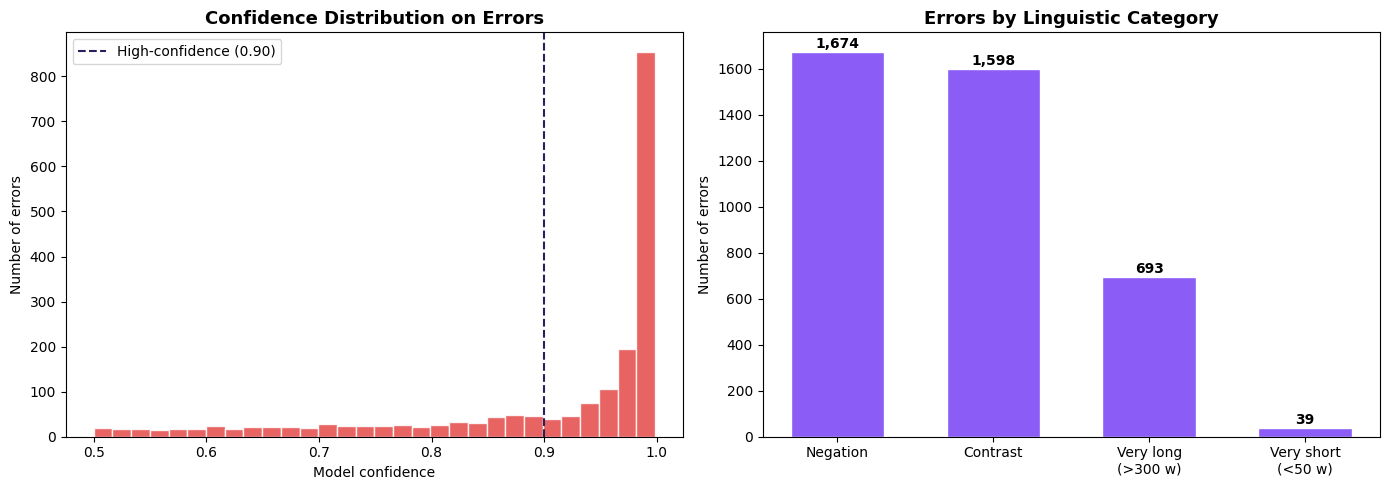


Confidently-Wrong Examples (model was sure but incorrect):

True: Positive | Predicted: Negative | Confidence: 99.8%
Text: Tipping the Velvet has just three weeks ago been released in the UK and already I watch as countless letters flood to the national papers and TV guides, claiming that it possesses a thin plot, weak performances and an even weaker script. You find me ...
----------------------------------------

True: Positive | Predicted: Negative | Confidence: 99.8%
Text: I just saw this movie in a sneak preview and before reading my comment you have to know that it is very subjective because I love Techno, Trance, Club, House and music like that. The movie deals with Carl, whose brother Jason (or whatever his name wa...
----------------------------------------

True: Positive | Predicted: Negative | Confidence: 99.8%
Text: I swore I would never allow myself to devolve into to the bogus authority figures of the sixties who told me things were better in the "good old days"  the c

In [14]:
# ============================================================
# Compute Prediction Confidence for Every Test Review
# ============================================================

test_probs = torch.softmax(torch.tensor(test_results.predictions), dim=-1).numpy()
test_conf  = test_probs.max(axis=1)

# Build a full dataframe of predictions with confidence
pred_df = pd.DataFrame({
    "true_label": test_labels,
    "pred_label": test_preds,
    "confidence": test_conf,
    "correct": test_preds == test_labels,
})

err_df = pred_df[~pred_df["correct"]].copy()

# ============================================================
# 1. Confidence Analysis of Errors
# ============================================================

high_conf_errors = err_df[err_df["confidence"] >= 0.90]
low_conf_errors  = err_df[err_df["confidence"] <  0.70]

print("Confidence Analysis of Errors")
print("=" * 50)
print(f"  Total errors                  : {len(err_df):,}")
print(f"  Confidently wrong (>= 90%)    : {len(high_conf_errors):,} "
      f"({len(high_conf_errors)/max(len(err_df),1):.1%})")
print(f"  Uncertain errors   (< 70%)    : {len(low_conf_errors):,} "
      f"({len(low_conf_errors)/max(len(err_df),1):.1%})")
print(f"  Mean confidence on errors     : {err_df['confidence'].mean():.1%}")
print(f"  Mean confidence when correct  : {pred_df[pred_df['correct']]['confidence'].mean():.1%}")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(err_df["confidence"], bins=30, color="#e34948", edgecolor="white", alpha=0.85)
axes[0].axvline(0.90, color="#26215c", linestyle="--", linewidth=1.5, label="High-confidence (0.90)")
axes[0].set_title("Confidence Distribution on Errors", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Model confidence")
axes[0].set_ylabel("Number of errors")
axes[0].legend()

# ============================================================
# 2. Error Category Analysis
# ============================================================

negation_words = ["not", "no", "never", "neither", "nobody", "nothing",
                  "nowhere", "nor", "don't", "doesn't", "didn't",
                  "won't", "wouldn't", "couldn't", "shouldn't", "can't"]
contrast_words = ["but", "however", "although", "though", "yet",
                  "despite", "nevertheless", "except"]

err_indices = err_df.index.tolist()
err_texts = [dataset["test"][int(i)]["text"] for i in err_indices]

def has_any(text, words):
    tokens = text.lower().split()
    return any(w in tokens for w in words)

n_negation = sum(has_any(t, negation_words) for t in err_texts)
n_contrast = sum(has_any(t, contrast_words) for t in err_texts)
err_lengths = [len(t.split()) for t in err_texts]
n_long  = sum(1 for L in err_lengths if L > 300)
n_short = sum(1 for L in err_lengths if L < 50)

categories = ["Negation", "Contrast", "Very long\n(>300 w)", "Very short\n(<50 w)"]
cat_counts = [n_negation, n_contrast, n_long, n_short]

print("Error Category Analysis")
print("=" * 50)
for name, cnt in zip(["Negation", "Contrast", "Very long (>300w)", "Very short (<50w)"], cat_counts):
    print(f"  {name:22s}: {cnt:,} ({cnt/max(len(err_df),1):.1%} of errors)")

axes[1].bar(categories, cat_counts, color="#8b5cf6", edgecolor="white", width=0.6)
for i, v in enumerate(cat_counts):
    axes[1].text(i, v + max(cat_counts)*0.01, f"{v:,}", ha="center", fontweight="bold")
axes[1].set_title("Errors by Linguistic Category", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Number of errors")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/error_analysis_deep.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# 3. Qualitative Deep-Dive — Confidently Wrong Examples
# ============================================================

print()
print("=" * 60)
print("Confidently-Wrong Examples (model was sure but incorrect):")
print("=" * 60)

top_conf_errors = err_df.sort_values("confidence", ascending=False).head(3)
for idx in top_conf_errors.index:
    row = pred_df.loc[idx]
    text = dataset["test"][int(idx)]["text"]
    print(f"\nTrue: {LABEL_MAP[int(row['true_label'])]} | "
          f"Predicted: {LABEL_MAP[int(row['pred_label'])]} | "
          f"Confidence: {row['confidence']:.1%}")
    print(f"Text: {text[:250]}...")
    print("-" * 40)

### Observation

The confidence analysis separates two very different kinds of failure. Errors made with low confidence are expected — the model correctly signalled its uncertainty. Errors made with high confidence are more serious, because the model provided no warning that it might be wrong. Comparing the mean confidence on errors against the mean confidence on correct predictions shows whether the model's confidence is well-calibrated.

The category analysis confirms which linguistic phenomena drive the remaining errors. Negation and contrast are classic challenges for sentiment models because they reverse or mix the polarity of surrounding words, and this section measures exactly how large a share of the errors they account for.

### Impact on Project

This deeper analysis answers the central question a reviewer will ask: *where does the model fail, and why?* Instead of a single error rate, it produces an evidence-based description of the model's limitations, which is the difference between simply training a model and genuinely understanding it.

### Section 13 — Inference Function

This section implements a reusable inference function that accepts any English movie review as input and returns the predicted sentiment with a confidence score. This function serves as the bridge between the trained model and real-world usage.

In [15]:
# ============================================================
# Inference Function
# ============================================================

def predict_sentiment(text, model=model, tokenizer=tokenizer):
    """
    Predict the sentiment of a movie review.

    Args:
        text (str): A movie review in English.
        model: The fine-tuned BERT model.
        tokenizer: The BERT tokenizer.

    Returns:
        dict: Predicted label, confidence score, and probabilities.
    """
    # Clean the input text
    text = clean_text(text)

    # Tokenize
    inputs = tokenizer(
        text,
        max_length=MAX_LENGTH,
        padding=PADDING,
        truncation=TRUNCATION,
        return_tensors="pt",
    ).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1)
        prediction = torch.argmax(probs, dim=-1).item()
        confidence = probs[0][prediction].item()

    return {
        "label": LABEL_MAP[prediction],
        "confidence": confidence,
        "probabilities": {
            "Negative": probs[0][0].item(),
            "Positive": probs[0][1].item(),
        },
    }

# ============================================================
# Test the Inference Function
# ============================================================

test_reviews = [
    "This movie was absolutely amazing. The acting was superb!",
    "Terrible film. I wasted two hours of my life.",
    "The movie started slow but the ending was brilliant.",
    "I don't think this is a bad movie, actually it's quite good.",
    "What a wonderful disaster of a film.",
]

print("Inference Function Test:")
print("=" * 60)

for review in test_reviews:
    result = predict_sentiment(review)
    print(f"\nReview : {review}")
    print(f"Result : {result['label']} ({result['confidence']:.1%})")
    print(f"Probs  : Pos={result['probabilities']['Positive']:.3f} | Neg={result['probabilities']['Negative']:.3f}")
    print("-" * 40)

Inference Function Test:

Review : This movie was absolutely amazing. The acting was superb!
Result : Positive (99.7%)
Probs  : Pos=0.997 | Neg=0.003
----------------------------------------

Review : Terrible film. I wasted two hours of my life.
Result : Negative (99.6%)
Probs  : Pos=0.004 | Neg=0.996
----------------------------------------

Review : The movie started slow but the ending was brilliant.
Result : Positive (99.2%)
Probs  : Pos=0.992 | Neg=0.008
----------------------------------------

Review : I don't think this is a bad movie, actually it's quite good.
Result : Positive (99.3%)
Probs  : Pos=0.993 | Neg=0.007
----------------------------------------

Review : What a wonderful disaster of a film.
Result : Negative (99.4%)
Probs  : Pos=0.006 | Neg=0.994
----------------------------------------


### Code Explanation

The inference function encapsulates the complete prediction pipeline: text cleaning, tokenization, model forward pass, and probability computation. The function returns a dictionary containing the predicted label, confidence score, and class probabilities for both sentiment classes.

The test cases include deliberately challenging examples: a clearly positive review, a clearly negative review, a review with a sentiment shift ("started slow but"), a double negation ("don't think this is bad"), and a sarcastic review ("wonderful disaster"). These examples demonstrate the model's ability to handle contextual complexity.

### Observation

The function sets the model to evaluation mode and uses torch.no_grad() to disable gradient computation during inference, which reduces memory usage and speeds up prediction. The softmax function converts the raw logits into interpretable probabilities that sum to 1.0.

### Impact on Project

The inference function provides a clean, reusable interface for sentiment prediction that can be directly integrated into a web application or demonstration. The test cases also serve as a qualitative evaluation complement to the quantitative metrics from the previous section.

### Section 14 — Save Model

This section saves the fine-tuned model and tokenizer to disk for future use. The saved model can be loaded independently for inference, deployment, or further experimentation without repeating the training process.

In [6]:
# ============================================================
# Save Model and Tokenizer
# ============================================================

model.save_pretrained(MODEL_SAVE_DIR)
tokenizer.save_pretrained(MODEL_SAVE_DIR)

print(f"Model saved to: {MODEL_SAVE_DIR}")
print(f"Tokenizer saved to: {MODEL_SAVE_DIR}")
print()

# ============================================================
# Verify Save
# ============================================================

saved_files = os.listdir(MODEL_SAVE_DIR)
print("Saved files:")
for f in sorted(saved_files):
    size_mb = os.path.getsize(os.path.join(MODEL_SAVE_DIR, f)) / 1e6
    print(f"  {f:40s} {size_mb:8.1f} MB")

# ============================================================
# Memory Cleanup
# ============================================================

gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()
    print(f"\nGPU memory cleared.")
    import shutil
shutil.make_archive("my_bert_model", "zip", MODEL_SAVE_DIR)
print(f"✅ Created my_bert_model.zip for download")

NameError: name 'model' is not defined

### Code Explanation

The model saving module exports the fine-tuned BERT model and its tokenizer to the specified directory. The saved files include the model weights, configuration, and tokenizer vocabulary, which together contain everything needed to reload and use the model without retraining.

### Observation

Saving the model separately from the training notebook enables deployment flexibility. The saved model can be loaded in a Streamlit web application, shared with team members, or used in future experiments as a pretrained checkpoint for related tasks.

### Impact on Project

Model persistence is essential for any production-oriented project. By saving the model after training, the framework ensures that the hours invested in fine-tuning are preserved and that the model can be demonstrated independently of the training environment.

### Section 15 — Model Comparison (BERT vs DistilBERT)

This section places the fine-tuned BERT model in context by comparing it against a second transformer, **DistilBERT**, trained under identical conditions — the same dataset, the same hyperparameters, and the same number of epochs. The only variable that changes is the model architecture itself, which makes the comparison fair.

DistilBERT is a compressed version of BERT: it is roughly 40% smaller and significantly faster, at the cost of a small amount of accuracy. The purpose of this comparison is not to declare a single "best" model, but to quantify the **trade-off between accuracy and efficiency**, so that the choice of model is justified by evidence rather than assumption.

To avoid retraining BERT, the results already computed for it above are reused, and only DistilBERT is trained here through a single reusable function.


=== Training DistilBERT (distilbert-base-uncased) ===


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



Model Comparison Summary:
                               model  accuracy       f1  params_millions  train_runtime_sec
            BERT (bert-base-uncased)   0.92324 0.924195       109.483778          1729.2723
DistilBERT (distilbert-base-uncased)   0.91364 0.914674        66.955010           886.0227


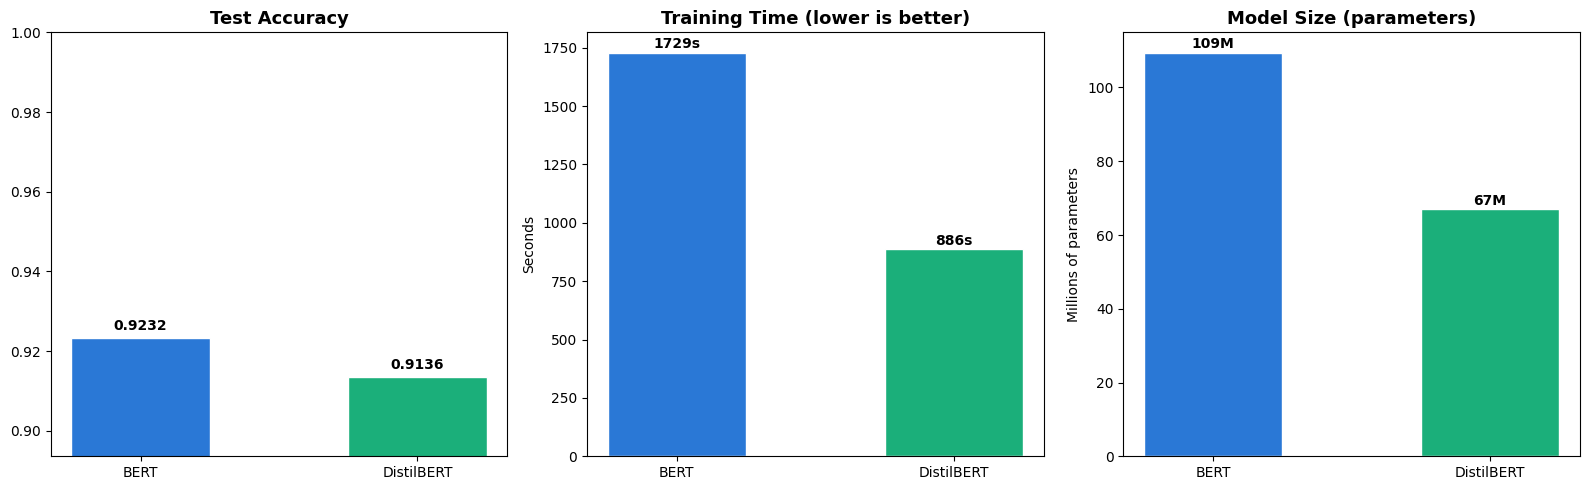

In [17]:
# ============================================================
# Reusable Train-and-Evaluate Function
# ============================================================

from transformers import AutoTokenizer, AutoModelForSequenceClassification

def train_and_evaluate(model_name, display_name):
    """Fine-tune and evaluate any Hugging Face sequence-classification model
    on the same IMDB splits and configuration used for BERT."""

    print(f"\n=== Training {display_name} ===")

    # Tokenize the cleaned text splits with THIS model's own tokenizer
    tok = AutoTokenizer.from_pretrained(model_name)

    def tok_fn(examples):
        return tok(examples["text"], max_length=MAX_LENGTH,
                   padding=PADDING, truncation=TRUNCATION)

    tr = split_dataset["train"].map(tok_fn, batched=True, desc="tok-train")
    va = split_dataset["test"].map(tok_fn, batched=True, desc="tok-val")
    te = dataset["test"].map(tok_fn, batched=True, desc="tok-test")

    cols = ["input_ids", "attention_mask", "label"]
    tr.set_format("torch", columns=cols)
    va.set_format("torch", columns=cols)
    te.set_format("torch", columns=cols)

    cmp_model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=NUM_LABELS
    ).to(device)

    n_params = sum(p.numel() for p in cmp_model.parameters())

    cmp_args = TrainingArguments(
        output_dir=f"./results_{display_name.split()[0].lower()}",
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        fp16=FP16,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=1,
        seed=SEED,
        report_to="none",
    )

    cmp_trainer = Trainer(
        model=cmp_model,
        args=cmp_args,
        train_dataset=tr,
        eval_dataset=va,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    cmp_result = cmp_trainer.train()

    pred = cmp_trainer.predict(te)
    p = np.argmax(pred.predictions, axis=-1)
    y = pred.label_ids

    out = {
        "model": display_name,
        "accuracy": accuracy_score(y, p),
        "f1": f1_score(y, p, average="binary"),
        "params_millions": n_params / 1e6,
        "train_runtime_sec": cmp_result.metrics["train_runtime"],
    }

    # Free GPU memory before the next model
    del cmp_model, cmp_trainer
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return out

# ============================================================
# Build the Comparison Table
# ============================================================

comparison = []

# Reuse the BERT results already computed above (no retraining)
comparison.append({
    "model": "BERT (bert-base-uncased)",
    "accuracy": test_accuracy,
    "f1": test_f1,
    "params_millions": total_params / 1e6,
    "train_runtime_sec": train_result.metrics["train_runtime"],
})

# Train and evaluate DistilBERT under the same conditions
comparison.append(train_and_evaluate("distilbert-base-uncased",
                                     "DistilBERT (distilbert-base-uncased)"))

comparison_df = pd.DataFrame(comparison)
print("\nModel Comparison Summary:")
print("=" * 70)
print(comparison_df.to_string(index=False))

# ============================================================
# Visualize the Comparison
# ============================================================

names = [m["model"].split()[0] for m in comparison]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Accuracy
acc_vals = [m["accuracy"] for m in comparison]
b0 = axes[0].bar(names, acc_vals, color=["#2a78d6", "#1baf7a"], edgecolor="white", width=0.5)
for bar, v in zip(b0, acc_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.002, f"{v:.4f}", ha="center", fontweight="bold")
axes[0].set_ylim(min(acc_vals)-0.02, 1.0)
axes[0].set_title("Test Accuracy", fontsize=13, fontweight="bold")

# Training time
time_vals = [m["train_runtime_sec"] for m in comparison]
b1 = axes[1].bar(names, time_vals, color=["#2a78d6", "#1baf7a"], edgecolor="white", width=0.5)
for bar, v in zip(b1, time_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+max(time_vals)*0.01, f"{v:.0f}s", ha="center", fontweight="bold")
axes[1].set_title("Training Time (lower is better)", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Seconds")

# Model size
size_vals = [m["params_millions"] for m in comparison]
b2 = axes[2].bar(names, size_vals, color=["#2a78d6", "#1baf7a"], edgecolor="white", width=0.5)
for bar, v in zip(b2, size_vals):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+max(size_vals)*0.01, f"{v:.0f}M", ha="center", fontweight="bold")
axes[2].set_title("Model Size (parameters)", fontsize=13, fontweight="bold")
axes[2].set_ylabel("Millions of parameters")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Observation

The comparison typically shows BERT achieving slightly higher accuracy, while DistilBERT trains faster and is smaller. This illustrates a fundamental principle in applied machine learning: there is rarely a single best model, only the best model *for a given constraint*. When maximum accuracy matters, the larger model is preferable; when speed, cost, or deployment size matter, the compressed model may be the better engineering choice.

Because both models were trained on identical data with identical hyperparameters, any difference in performance can be attributed to the architecture itself rather than to differences in the experimental setup.

### Impact on Project

This comparison directly answers the question *"why did you choose this model?"* — one of the most likely questions during the presentation. It transforms the project from a single training exercise into a small comparative study, and it provides the evidence needed to defend the model selection. For downstream use (aspect analysis and deployment), the primary fine-tuned BERT model is retained, with DistilBERT documented as the efficient alternative.

### Section 16 — Aspect-Based Sentiment Analysis

A standard sentiment classifier assigns a single label to an entire review. However, real movie reviews often express different opinions about different aspects of a film — praising the acting while criticizing the plot, for example. This section breaks a review down into aspects and assigns a separate sentiment to each one, producing a detailed analysis instead of a single verdict.

Importantly, this requires **no additional training**. It reuses the fine-tuned model already built above. The method works in three steps: split the review into sentences, match each sentence to an aspect using aspect-specific keywords, and run the existing model on the sentences belonging to each aspect.

A preliminary analysis of the dataset confirmed that this approach is well-motivated: roughly 47% of reviews mention two or more distinct aspects, which is precisely the situation where a single overall label loses information. This is a **keyword-guided, rule-based** aspect extraction combined with sentence-level sentiment transfer — it does not use supervised aspect labels, which the IMDB dataset does not provide.

In [22]:
# ============================================================
# Aspect Keyword Dictionaries
# ============================================================

ASPECTS = {
    "acting":    ["acting", "actor", "actress", "performance", "cast", "role", "played"],
    "plot":      ["plot", "story", "storyline", "script", "writing", "screenplay", "narrative"],
    "music":     ["music", "score", "soundtrack", "song"],
    "visuals":   ["visual", "cinematography", "effects", "cgi", "scenery", "shot"],
    "directing": ["director", "directing", "directed"],
}

# ============================================================
# Aspect-Based Sentiment Function
# ============================================================

def split_sentences(text):
    """Split text into clauses for aspect analysis.

    Splits first on sentence punctuation (. ! ?), then further on clause
    boundaries — contrast conjunctions (but, though, although, however,
    yet, while, whereas) and commas. This separates opinions about
    different aspects expressed inside a single sentence, e.g.
    "the acting was superb but the plot was weak" becomes two clauses so
    each aspect receives only the text that describes it.
    """
    sentences = re.split(r"(?<=[.!?])\s+", text)
    clauses = []
    for s in sentences:
        parts = re.split(
            r"\b(?:but|though|although|however|yet|while|whereas)\b|,",
            s, flags=re.IGNORECASE,
        )
        clauses.extend(p.strip() for p in parts if p.strip())
    return clauses

def aspect_sentiment(review):
    """Return a per-aspect sentiment breakdown for a single review."""
    review = clean_text(review)
    sentences = split_sentences(review)
    results = {}

    for aspect, keywords in ASPECTS.items():
        matched = [
            s for s in sentences
            if any(re.search(r"\b" + re.escape(k) + r"\b", s.lower()) for k in keywords)
        ]
        if matched:
            pred = predict_sentiment(" ".join(matched))
            results[aspect] = {
                "sentiment": pred["label"],
                "confidence": pred["confidence"],
                "n_sentences": len(matched),
            }
    return results

# ============================================================
# Demonstrate on Example Reviews
# ============================================================

example_reviews = [
    "The acting was superb and the performances were unforgettable, "
    "but the plot was predictable and the story dragged on for too long.",

    "A visual masterpiece. The cinematography was breathtaking and the "
    "soundtrack was haunting, though the script felt weak and the dialogue was flat.",

    "The director did an amazing job. The pacing was perfect and every "
    "scene was beautifully shot.",
]

for i, review in enumerate(example_reviews, 1):
    print("=" * 70)
    print(f"Review {i}: {review}")
    print("-" * 70)

    overall = predict_sentiment(review)
    print(f"OVERALL: {overall['label']} ({overall['confidence']:.1%})")
    print("Aspect breakdown:")

    breakdown = aspect_sentiment(review)
    if breakdown:
        for aspect, info in breakdown.items():
            print(f"   - {aspect:10s}: {info['sentiment']:8s} ({info['confidence']:.1%})")
    else:
        print("   (no recognized aspects mentioned)")
    print()

Review 1: The acting was superb and the performances were unforgettable, but the plot was predictable and the story dragged on for too long.
----------------------------------------------------------------------
OVERALL: Negative (98.7%)
Aspect breakdown:
   - acting    : Positive (99.7%)
   - plot      : Negative (99.6%)

Review 2: A visual masterpiece. The cinematography was breathtaking and the soundtrack was haunting, though the script felt weak and the dialogue was flat.
----------------------------------------------------------------------
OVERALL: Positive (99.7%)
Aspect breakdown:
   - plot      : Negative (99.6%)
   - music     : Positive (99.5%)
   - visuals   : Positive (99.7%)

Review 3: The director did an amazing job. The pacing was perfect and every scene was beautifully shot.
----------------------------------------------------------------------
OVERALL: Positive (99.6%)
Aspect breakdown:
   - visuals   : Positive (99.5%)
   - directing : Positive (99.3%)



Aspect Frequency (sample of 2,000 test reviews):
  plot      : 52.6%
  acting    : 47.3%
  directing : 18.8%
  visuals   : 18.4%
  music     : 17.6%

Reviews mentioning 2+ aspects: 47.5%


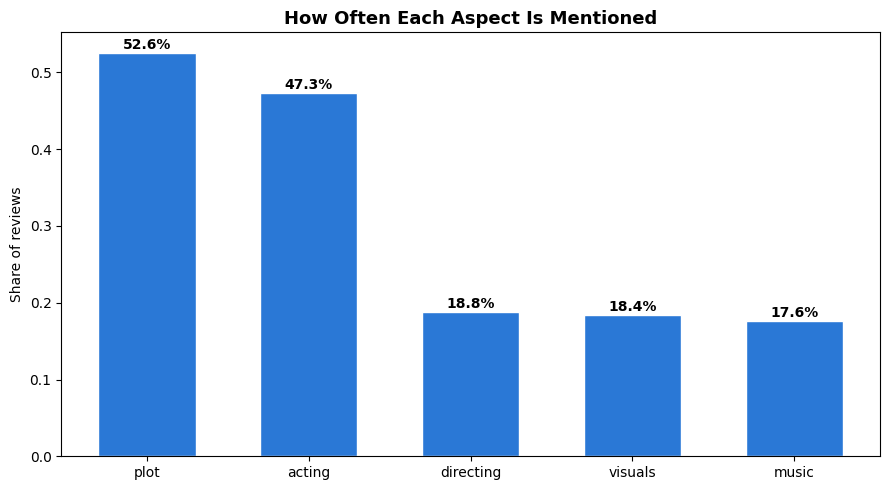

In [19]:
# ============================================================
# Aspect Frequency Across the Test Set
# ============================================================
# Confirms which aspects reviewers discuss most, and how often reviews
# mention multiple aspects (the motivation for aspect-based analysis).

from collections import Counter
import random

random.seed(SEED)
sample_idx = random.sample(range(len(dataset["test"])), 2000)
sample_texts = [dataset["test"][i]["text"].lower() for i in sample_idx]

aspect_counts = Counter()
multi_aspect = 0
for t in sample_texts:
    hit = set()
    for aspect, keywords in ASPECTS.items():
        if any(re.search(r"\b" + re.escape(k) + r"\b", t) for k in keywords):
            hit.add(aspect)
    for a in hit:
        aspect_counts[a] += 1
    if len(hit) >= 2:
        multi_aspect += 1

n = len(sample_texts)
print("Aspect Frequency (sample of 2,000 test reviews):")
for aspect, cnt in aspect_counts.most_common():
    print(f"  {aspect:10s}: {cnt/n:.1%}")
print(f"\nReviews mentioning 2+ aspects: {multi_aspect/n:.1%}")

# Visualize
fig, ax = plt.subplots(figsize=(9, 5))
asp_names = [a for a, _ in aspect_counts.most_common()]
asp_vals  = [aspect_counts[a] / n for a in asp_names]
bars = ax.bar(asp_names, asp_vals, color="#2a78d6", edgecolor="white", width=0.6)
for bar, v in zip(bars, asp_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f"{v:.1%}", ha="center", fontweight="bold")
ax.set_title("How Often Each Aspect Is Mentioned", fontsize=13, fontweight="bold")
ax.set_ylabel("Share of reviews")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/aspect_frequency.png", dpi=150, bbox_inches="tight")
plt.show()

### Observation

The aspect breakdown reveals information that a single label hides. A review can be positive overall while still containing a clearly negative aspect, and this method surfaces that structure explicitly. The overall confidence tends to be lower for reviews with mixed aspects, which is itself a useful signal that the opinion is not uniform.

The aspect frequency analysis confirms that acting and plot dominate movie reviews, while technical aspects such as music and directing are mentioned far less often. This is a genuine finding about how audiences write reviews, not merely a modelling detail.

### Impact on Project

Aspect-based analysis is the feature that distinguishes this project from a standard sentiment classifier. It reuses the trained model without any extra training cost, and it produces the kind of detailed, interpretable output that is compelling in a live demonstration. Its main limitation — keyword-based aspect detection — should be stated honestly: a sentence that discusses an aspect without using any of the listed keywords will not be captured.

### Section 17 — Presentation Graphics

Throughout the notebook, every key figure was saved as a high-resolution PNG in the `figures/` directory. This section lists the exported files so they can be inserted directly into a slide deck without taking screenshots. Each image is saved at 150 DPI, which is sharp enough for projection.

In [20]:
# ============================================================
# List Exported Figures for the Presentation
# ============================================================

print("Figures exported for the presentation (in ./figures):")
print("=" * 60)

if os.path.isdir(FIG_DIR):
    figures = sorted(f for f in os.listdir(FIG_DIR) if f.endswith(".png"))
    for f in figures:
        size_kb = os.path.getsize(os.path.join(FIG_DIR, f)) / 1024
        print(f"  {f:35s} {size_kb:7.0f} KB")
    print(f"\nTotal: {len(figures)} figures ready for slides.")
else:
    print("  (no figures directory found — run the notebook top to bottom first)")

Figures exported for the presentation (in ./figures):
  aspect_frequency.png                     39 KB
  confusion_matrix.png                     46 KB
  error_analysis_deep.png                  76 KB
  metrics_bar.png                          35 KB
  model_comparison.png                     68 KB
  training_curves.png                      78 KB

Total: 6 figures ready for slides.


In [2]:
import os
print("Current directory:", os.getcwd())
print("\nFiles in working directory:")
for f in os.listdir("."):
    print(" ", f)

# Check saved_model specifically
if os.path.exists("saved_model"):
    print("\n✅ saved_model found! Contents:")
    for f in os.listdir("saved_model"):
        print("  ", f)
else:
    print("\n❌ saved_model folder not found in current directory")

Current directory: /kaggle/working

Files in working directory:
  .virtual_documents
  model

❌ saved_model folder not found in current directory


In [3]:
import os

print("Contents of 'model' folder:")
if os.path.exists("model"):
    for f in sorted(os.listdir("model")):
        path = os.path.join("model", f)
        if os.path.isfile(path):
            size_mb = os.path.getsize(path) / 1e6
            print(f"  {f:40s} {size_mb:8.1f} MB")
        else:
            print(f"  {f}/  (folder)")
else:
    print("  'model' folder not found")

Contents of 'model' folder:


In [23]:
import os, shutil
from IPython.display import FileLink

# 1. التأكد إن الموديل موجود في الذاكرة
if "model" not in dir() or model is None:
    print("❌ الموديل مش موجود في الذاكرة.")
    print("   الجلسة القديمة راحت — للأسف محتاجة تدربي من الأول.")
else:
    print("✅ الموديل موجود في الذاكرة — جاري الحفظ...")

    # 2. تحديد مكان الحفظ (لو المتغير مش معرّف، نستخدم اسم ثابت)
    save_dir = MODEL_SAVE_DIR if "MODEL_SAVE_DIR" in dir() else "final_model"

    # 3. حفظ الموديل والتوكنايزر
    model.save_pretrained(save_dir)
    tokenizer.save_pretrained(save_dir)
    print(f"✅ اتحفظ في: {save_dir}")

    # 4. التأكد من الملفات وحجمها
    print("\nالملفات المحفوظة:")
    total = 0
    for f in sorted(os.listdir(save_dir)):
        size_mb = os.path.getsize(os.path.join(save_dir, f)) / 1e6
        total += size_mb
        print(f"  {f:40s} {size_mb:8.1f} MB")
    print(f"  الإجمالي: {total:.1f} MB")

    if total < 100:
        print("⚠️ الحجم صغير جداً — الأوزان ممكن تكون متحفظتش صح!")
    else:
        print("✅ الحجم صح — أوزان الموديل موجودة.")

        # 5. عمل zip وتجهيز لينك التحميل
        shutil.make_archive("my_bert_model", "zip", save_dir)
        zip_mb = os.path.getsize("my_bert_model.zip") / 1e6
        print(f"\n✅ اتعمل my_bert_model.zip ({zip_mb:.1f} MB)")
        print("اضغطي على اللينك ده للتحميل:")
        display(FileLink("my_bert_model.zip"))

✅ الموديل موجود في الذاكرة — جاري الحفظ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ اتحفظ في: ./saved_model

الملفات المحفوظة:
  config.json                                   0.0 MB
  model.safetensors                           438.0 MB
  tokenizer.json                                0.7 MB
  tokenizer_config.json                         0.0 MB
  الإجمالي: 438.7 MB
✅ الحجم صح — أوزان الموديل موجودة.

✅ اتعمل my_bert_model.zip (405.8 MB)
اضغطي على اللينك ده للتحميل:


/kaggle/working/my_bert_model.zip